# GCN-Align - Entity Alignment on DBP15K

> **Cross-lingual Knowledge Graph Alignment via Graph Convolutional Networks**
> Zhichun Wang, Qingsong Lv, Xiaohan Lan, Yu Zhang (*EMNLP 2018*)
> Source: https://aclanthology.org/D18-1032.pdf

A **self-contained** notebook (it imports nothing from an external package): the whole engine
is defined in the cells below. The same implementation is available in the `code/` package
(`code/src/models/gcnalign.py`, class `GCNAlignTrainer` in `code/src/trainer.py`).

## The GCN-Align idea
Two aligned entities across KGs have **similar neighbourhoods**. GCN-Align embeds the entities
of both KGs into a **shared space** with a **2-layer GCN whose weights are shared** between the
two graphs, so that structurally equivalent entities get similar embeddings.

1. **Adjacency weighted by relation *functionality***: for a relation `r`,
   `fun(r)=#heads/#triples` and `ifun(r)=#tails/#triples`; for a triple `(h,r,t)` we accumulate
   `M[h,t] += max(ifun(r),0.3)` and `M[t,h] += max(fun(r),0.3)`; self-loops then symmetric
   normalisation `D^{-1/2}(M+I)D^{-1/2}`.
2. **2-layer shared GCN**: `H' = A_hat H W` (linear propagation here; see Notes).
3. **Alignment loss**: a margin on the **L1 distance** between embeddings of the *seed* pairs,
   negatives drawn uniformly from all entities.

This notebook implements the **structure channel (SE)**; attributes (AE) are not used (the
DBP15K split loaded here is structure-only).

## Results (DBP15K zh_en, 30% seed, structure SE)
| | Hit@1 | Hit@5 | Hit@10 | MRR |
|---|---:|---:|---:|---:|
| **This notebook** | ~0.38 | ~0.62 | ~0.68 | ~0.49 |
| GCN-Align SE (paper) | 0.384 | - | 0.703 | - |

## Metrics: **MRR, Hit@1, Hit@5, Hit@10** (+ CSLS).

---
## 1. Environment, imports and style

In [1]:
import os, sys, csv, time, random, logging
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, field
from collections import Counter

import yaml
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import tqdm          # plain terminal tqdm (not the notebook widget)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent
print("Project root :", PROJECT_ROOT)
print("PyTorch      :", torch.__version__)
print("CUDA         :", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

SEED = 2024
set_seed(SEED)
torch.backends.cudnn.benchmark = True

Project root : /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k
PyTorch      : 2.5.1+cu121
CUDA         : True | NVIDIA GeForce RTX 3090


### 1.1 Modern dark theme (identical to `code/src/utils/plotting.py`)

In [2]:
"""Modern dark-theme plotting helpers.

A single :func:`set_modern_dark_style` configures Matplotlib with a clean,
GitHub-dark-inspired palette so every figure (training curves, EDA, metrics)
shares a consistent, modern look. The plotting functions below are used by the
trainer and can be reused from the notebook.
"""


# GitHub-dark-inspired palette
BG = "#0d1117"
PANEL = "#161b22"
GRID = "#21262d"
EDGE = "#30363d"
FG = "#c9d1d9"
TITLE = "#e6edf3"
MUTED = "#8b949e"
CYCLE = ["#58a6ff", "#3fb950", "#f778ba", "#ffa657", "#a371f7", "#56d4dd", "#e3b341"]


def set_modern_dark_style():
    """Apply the modern dark theme globally (idempotent)."""
    mpl.rcParams.update({
        "figure.facecolor": BG,
        "figure.edgecolor": BG,
        "savefig.facecolor": BG,
        "savefig.edgecolor": BG,
        "axes.facecolor": PANEL,
        "axes.edgecolor": EDGE,
        "axes.labelcolor": FG,
        "axes.titlecolor": TITLE,
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.grid": True,
        "axes.axisbelow": True,
        "axes.linewidth": 1.0,
        "grid.color": GRID,
        "grid.linestyle": "--",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.7,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "text.color": FG,
        "legend.facecolor": PANEL,
        "legend.edgecolor": EDGE,
        "legend.framealpha": 0.9,
        "lines.linewidth": 2.2,
        "lines.markersize": 5,
        "lines.solid_capstyle": "round",
        "font.size": 11,
        "figure.dpi": 120,
        "axes.prop_cycle": mpl.cycler(color=CYCLE),
    })


def style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent spine/tick styling to an Axes."""
    if title:
        ax.set_title(title, pad=12)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(length=0)
    return ax


def plot_loss_curves(loss_hist, ax=None, keys=("loss", "kge", "align", "pseudo")):
    """Plot per-epoch loss components from a list of dicts (with 'epoch')."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    ep = [h["epoch"] for h in loss_hist]
    labels = {"loss": "total", "kge": "kge (TransE)",
              "align": "align (seed)", "pseudo": "align (pseudo)"}
    for key in keys:
        ax.plot(ep, [h.get(key, 0.0) for h in loss_hist], label=labels.get(key, key))
    ax.legend()
    return style_axes(ax, "Training loss", "epoch", "loss")


def plot_metric_curves(metric_hist, ax=None):
    """Plot per-eval metric history from a list of dicts (with 'epoch')."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    ep = [h["epoch"] for h in metric_hist]
    for key in [k for k in metric_hist[0] if k != "epoch"]:
        ax.plot(ep, [h[key] for h in metric_hist], marker="o", label=key)
    ax.set_ylim(0, 1)
    ax.legend()
    return style_axes(ax, "Test metrics (avg direction)", "epoch", "score")

set_modern_dark_style()
print('Dark theme applique.')

Dark theme applique.


---
## 2. Configuration (YAML) and logging
Driven by **`configs/gcnalign_dbp15k.yaml`**. Code identical to `code/src/utils/config.py` and `logger.py`.

In [3]:
"""Configuration loading and run-directory bootstrap.

The whole experiment is driven by a single YAML file (see ``configs/``).
This module:
  * loads that YAML into a dotted-access namespace (``cfg.train.lr`` etc.),
  * creates a timestamped *run directory* under ``logging.output_dir``,
  * dumps the resolved config back to disk for reproducibility.

The logger is created separately by :mod:`src.utils.logger`.
"""




class Cfg(dict):
    """A ``dict`` that also supports attribute access, recursively.

    ``cfg.train.lr`` is equivalent to ``cfg["train"]["lr"]``. This keeps the
    code readable while still being a plain dict underneath (so it serialises
    straight back to YAML/JSON).
    """

    def __init__(self, d: dict | None = None):
        super().__init__()
        for k, v in (d or {}).items():
            self[k] = Cfg(v) if isinstance(v, dict) else v

    def __getattr__(self, name):
        try:
            return self[name]
        except KeyError as e:
            raise AttributeError(name) from e

    def __setattr__(self, name, value):
        self[name] = Cfg(value) if isinstance(value, dict) and not isinstance(value, Cfg) else value

    def to_plain(self):
        """Convert back to nested plain dicts (for YAML/JSON dumping)."""
        return {k: (v.to_plain() if isinstance(v, Cfg) else v) for k, v in self.items()}


def load_config(path: str | Path, project_root: str | Path | None = None) -> Cfg:
    """Load a YAML config file into a :class:`Cfg` namespace.

    ``project_root`` (defaults to the parent of ``configs/``) is recorded so
    relative data/output paths can be resolved consistently regardless of the
    current working directory.
    """
    path = Path(path).resolve()
    with open(path, "r", encoding="utf-8") as f:
        raw = yaml.safe_load(f)
    cfg = Cfg(raw)
    root = Path(project_root).resolve() if project_root else path.parent.parent
    cfg._project_root = str(root)
    cfg._config_path = str(path)
    return cfg


def make_run_dir(cfg: Cfg) -> Path:
    """Create (and return) the timestamped run directory for this experiment.

    Layout::

        <output_dir>/<experiment.name>_<YYYYmmdd-HHMMSS>/
            training.txt          (full training log)
            config_used.yaml      (snapshot of the resolved config)
            model.pt / model_best.pt
            embeddings.pt
            metrics.csv / loss.csv
            *.png                 (loss & metric curves)
    """
    root = Path(cfg._project_root)
    out = root / cfg.logging.output_dir
    stamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = out / f"{cfg.experiment.name}_{stamp}"
    run_dir.mkdir(parents=True, exist_ok=True)
    cfg._run_dir = str(run_dir)

    # snapshot the exact config used for this run
    with open(run_dir / cfg.logging.config_dump, "w", encoding="utf-8") as f:
        yaml.safe_dump(cfg.to_plain(), f, sort_keys=False, allow_unicode=True)
    return run_dir

In [4]:
"""Logging setup: write simultaneously to the console and to ``training.txt``."""




def get_logger(cfg: Cfg, run_dir: Path) -> logging.Logger:
    """Return a logger writing to both stdout and ``training.txt``.

    Re-callable safely (handlers are reset) so re-running the setup does not
    duplicate every log line.
    """
    logger = logging.getLogger(cfg.experiment.name)
    logger.setLevel(getattr(logging, cfg.logging.log_level.upper(), logging.INFO))
    logger.handlers.clear()
    logger.propagate = False

    fmt = logging.Formatter("%(asctime)s | %(levelname)-7s | %(message)s", "%H:%M:%S")

    fh = logging.FileHandler(run_dir / cfg.logging.log_file, mode="w", encoding="utf-8")
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    sh = logging.StreamHandler(sys.stdout)
    sh.setFormatter(fmt)
    logger.addHandler(sh)
    return logger

In [5]:
cfg = load_config(PROJECT_ROOT / "configs" / "gcnalign_dbp15k.yaml", project_root=PROJECT_ROOT)
cfg.experiment.seed = SEED
cfg.experiment.name = f"gcnalign_{cfg.data.lang}_{cfg.data.fold}"

run_dir = make_run_dir(cfg)
logger = get_logger(cfg, run_dir)
device = torch.device(cfg.experiment.device if torch.cuda.is_available() else "cpu")
logger.info(f"Run dir : {run_dir}")
logger.info(f"Device  : {device}")
print(yaml.safe_dump(cfg.to_plain(), sort_keys=False, allow_unicode=True))

03:57:16 | INFO    | Run dir : /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k/experiments/gcnalign_zh_en_0_3_20260601-035716
03:57:16 | INFO    | Device  : cuda
experiment:
  name: gcnalign_zh_en_0_3
  model: gcnalign
  seed: 2024
  device: cuda
data:
  root: Data/dbp15k
  lang: zh_en
  fold: '0_3'
  use_mtranse_format: true
model:
  embed_dim: 300
  n_layers: 2
  dropout: 0.0
  activation: false
  normalize_embeddings: true
train:
  epochs: 3000
  lr: 0.001
  optimizer: adam
  weight_decay: 0.0
  grad_clip: 0.0
  early_stop_patience: 0
  margin: 3.0
  k: 25
eval:
  every: 50
  hits_at:
  - 1
  - 5
  - 10
  metric: csls
  csls_k: 3
  eval_chunk: 1024
  direction: both
logging:
  output_dir: experiments
  log_file: training.txt
  config_dump: config_used.yaml
  save_best: true
  save_last: true
  checkpoint_name: model.pt
  embeddings_name: embeddings.pt
  metrics_csv: metrics.csv
  loss_csv: loss.csv
  plots:
    loss_curve: loss_curve.png
    metrics_curve: metrics_curve.png
  l

---
## 3. DBP15K data and weighted adjacency

JAPE/MTransE format (disjoint contiguous ids). Code identical to `code/src/data.py` (includes
GCN-Align's adjacency builder: `build_gcnalign_adj`, weighted by relation *functionality*).

In [6]:
"""DBP15K data loading + neighbourhood construction for NAEA.

Data layout (the clean JAPE / MTransE split we use, ``<lang>/mtranse/<fold>/``):

    ent_ids_1 / ent_ids_2 : "<id>\\t<uri>"   entities of KG1 (e.g. zh) / KG2 (en)
    rel_ids_1 / rel_ids_2 : "<id>\\t<uri>"   relations of KG1 / KG2
    triples_1 / triples_2 : "<h>\\t<r>\\t<t>"
    sup_pairs             : "<e1>\\t<e2>"    seed (training) alignments  (30% for 0_3)
    ref_pairs             : "<e1>\\t<e2>"    test alignments             (70% for 0_3)

Crucially, in this split the entity ids of KG1 and KG2 are **disjoint** and form
a single contiguous range ``0 .. num_entities-1``; likewise relation ids. That
lets us use one shared embedding table and index it directly.
"""




# --------------------------------------------------------------------------- #
#  Raw file readers
# --------------------------------------------------------------------------- #
def _read_id_uri(path: Path) -> dict[int, str]:
    d = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) >= 2:
                d[int(parts[0])] = parts[1]
    return d


def _read_triples(path: Path) -> np.ndarray:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            p = line.rstrip("\n").split("\t")
            if len(p) >= 3:
                rows.append((int(p[0]), int(p[1]), int(p[2])))
    return np.asarray(rows, dtype=np.int64)


def _read_pairs(path: Path) -> np.ndarray:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            p = line.rstrip("\n").split("\t")
            if len(p) >= 2:
                rows.append((int(p[0]), int(p[1])))
    return np.asarray(rows, dtype=np.int64)


# --------------------------------------------------------------------------- #
#  Container
# --------------------------------------------------------------------------- #
@dataclass
class DBP15K:
    """Everything the model/trainer needs, as numpy arrays + lookup dicts."""

    lang: str
    fold: str
    ent_uri: dict[int, str]            # global entity id -> uri
    rel_uri: dict[int, str]            # global relation id -> uri
    kg1_ents: np.ndarray               # entity ids belonging to KG1
    kg2_ents: np.ndarray               # entity ids belonging to KG2
    triples1: np.ndarray               # (M1, 3)  KG1 triples
    triples2: np.ndarray               # (M2, 3)  KG2 triples
    train_pairs: np.ndarray            # (S, 2)   seed alignments
    test_pairs: np.ndarray             # (T, 2)   test alignments
    num_entities: int = field(init=False)
    num_relations: int = field(init=False)

    def __post_init__(self):
        self.num_entities = int(max(self.ent_uri) + 1)
        self.num_relations = int(max(self.rel_uri) + 1)

    @property
    def triples(self) -> np.ndarray:
        return np.concatenate([self.triples1, self.triples2], axis=0)

    def summary(self) -> dict:
        return {
            "lang": self.lang,
            "fold": self.fold,
            "num_entities": self.num_entities,
            "num_relations": self.num_relations,
            "|KG1 ents|": len(self.kg1_ents),
            "|KG2 ents|": len(self.kg2_ents),
            "|KG1 triples|": len(self.triples1),
            "|KG2 triples|": len(self.triples2),
            "train_pairs": len(self.train_pairs),
            "test_pairs": len(self.test_pairs),
        }


def load_dbp15k(root: str | Path, lang: str, fold: str, use_mtranse: bool = True) -> DBP15K:
    base = Path(root) / lang / "mtranse" / fold if use_mtranse else Path(root) / lang / fold

    ent1 = _read_id_uri(base / "ent_ids_1")
    ent2 = _read_id_uri(base / "ent_ids_2")
    rel1 = _read_id_uri(base / "rel_ids_1")
    rel2 = _read_id_uri(base / "rel_ids_2")

    ent_uri = {**ent1, **ent2}
    rel_uri = {**rel1, **rel2}

    triples1 = _read_triples(base / "triples_1")
    triples2 = _read_triples(base / "triples_2")

    pair_train = "sup_pairs" if use_mtranse else "sup_ent_ids"
    pair_test = "ref_pairs" if use_mtranse else "ref_ent_ids"
    train_pairs = _read_pairs(base / pair_train)
    test_pairs = _read_pairs(base / pair_test)

    return DBP15K(
        lang=lang,
        fold=fold,
        ent_uri=ent_uri,
        rel_uri=rel_uri,
        kg1_ents=np.asarray(sorted(ent1), dtype=np.int64),
        kg2_ents=np.asarray(sorted(ent2), dtype=np.int64),
        triples1=triples1,
        triples2=triples2,
        train_pairs=train_pairs,
        test_pairs=test_pairs,
    )


# --------------------------------------------------------------------------- #
#  Neighbourhood construction
# --------------------------------------------------------------------------- #
def build_neighbors(data: DBP15K, max_neighbors: int, seed: int = 0):
    """Build padded neighbour tensors for the attention aggregator.

    For every entity ``e`` we collect its neighbours from all triples it
    participates in. A neighbour is a *(relation, entity, direction)* triplet:

      * out-edge ``(e, r, t)``  ->  neighbour ``t`` via ``r``, sign = -1
        (TransE: ``e ~= t - r``, so the message that reconstructs ``e`` is ``t - r``)
      * in-edge  ``(h, r, e)``  ->  neighbour ``h`` via ``r``, sign = +1
        (TransE: ``e ~= h + r``, message ``h + r``)

    Entities with more than ``max_neighbors`` neighbours are randomly
    sub-sampled; entities with fewer are zero-padded and masked.

    Returns four ``LongTensor``/``Tensor``/``BoolTensor`` of shape
    ``(num_entities, max_neighbors)``: ``(neigh_ent, neigh_rel, neigh_sign, mask)``.
    """
    rng = random.Random(seed)
    N = data.num_entities
    adj: list[list[tuple[int, int, int]]] = [[] for _ in range(N)]

    for arr in (data.triples1, data.triples2):
        for h, r, t in arr:
            adj[h].append((int(r), int(t), -1))   # out-edge:  e=h, message t - r
            adj[t].append((int(r), int(h), +1))   # in-edge:   e=t, message h + r

    K = max_neighbors
    neigh_ent = np.zeros((N, K), dtype=np.int64)
    neigh_rel = np.zeros((N, K), dtype=np.int64)
    neigh_sign = np.zeros((N, K), dtype=np.float32)
    mask = np.zeros((N, K), dtype=bool)

    for e in range(N):
        nbrs = adj[e]
        if len(nbrs) > K:
            nbrs = rng.sample(nbrs, K)
        for j, (r, ne, s) in enumerate(nbrs):
            neigh_rel[e, j] = r
            neigh_ent[e, j] = ne
            neigh_sign[e, j] = s
            mask[e, j] = True

    return (
        torch.from_numpy(neigh_ent),
        torch.from_numpy(neigh_rel),
        torch.from_numpy(neigh_sign),
        torch.from_numpy(mask),
    )


# --------------------------------------------------------------------------- #
#  Negative sampling helpers
# --------------------------------------------------------------------------- #
class TripleSampler:
    """Mini-batch iterator over triples with per-KG corrupted negatives.

    Negatives are produced by replacing the head *or* the tail with a uniformly
    random entity **from the same KG** (cross-KG corruptions would be trivial
    negatives and pollute the signal).
    """

    def __init__(self, data: DBP15K, device, neg: int = 5):
        self.device = device
        self.neg = neg
        t1 = torch.from_numpy(data.triples1)
        t2 = torch.from_numpy(data.triples2)
        kg = torch.cat([torch.zeros(len(t1), dtype=torch.long),
                        torch.ones(len(t2), dtype=torch.long)])
        self.triples = torch.cat([t1, t2], 0).to(device)        # (M,3)
        self.kg = kg.to(device)                                  # (M,)
        self.kg1_ents = torch.from_numpy(data.kg1_ents).to(device)
        self.kg2_ents = torch.from_numpy(data.kg2_ents).to(device)

    def __len__(self):
        return len(self.triples)

    def _rand_same_kg(self, kg_flags: torch.Tensor) -> torch.Tensor:
        """A random entity from the same KG as each row of ``kg_flags``."""
        n = kg_flags.shape[0]
        r1 = self.kg1_ents[torch.randint(len(self.kg1_ents), (n,), device=self.device)]
        r2 = self.kg2_ents[torch.randint(len(self.kg2_ents), (n,), device=self.device)]
        return torch.where(kg_flags == 0, r1, r2)

    def batches(self, batch_size: int, shuffle: bool = True):
        M = len(self.triples)
        order = torch.randperm(M, device=self.device) if shuffle else torch.arange(M, device=self.device)
        for s in range(0, M, batch_size):
            idx = order[s:s + batch_size]
            pos = self.triples[idx]                              # (B,3)
            kg = self.kg[idx]                                    # (B,)
            B = pos.shape[0]
            # repeat for `neg` corruptions
            pos_r = pos.repeat(self.neg, 1)                      # (B*neg,3)
            kg_r = kg.repeat(self.neg)
            neg = pos_r.clone()
            corrupt_head = torch.rand(B * self.neg, device=self.device) < 0.5
            rnd = self._rand_same_kg(kg_r)
            neg[:, 0] = torch.where(corrupt_head, rnd, neg[:, 0])
            neg[:, 2] = torch.where(~corrupt_head, rnd, neg[:, 2])
            yield pos, neg, kg


class AlignSampler:
    """Mini-batch iterator over alignment pairs with corrupted negatives.

    For a positive pair ``(e1, e2)`` we corrupt the right side (a KG2 entity)
    and the left side (a KG1 entity) to obtain negatives in both alignment
    directions. ``set_pairs`` lets the trainer inject bootstrapped pseudo-pairs.

    **Hard (nearest-neighbour) negatives.** If ``set_hard_negatives`` has been
    called, negatives are drawn from each pair's pre-computed nearest cross-KG
    candidates (the *confusable* entities) instead of uniformly at random - the
    epsilon-truncated negative sampling of BootEA/NAEA, which sharpens Hit@1. Any
    candidate that equals the gold target is replaced by a random one.
    """

    def __init__(self, data: DBP15K, device, neg: int = 5):
        self.device = device
        self.neg = neg
        self.kg1_ents = torch.from_numpy(data.kg1_ents).to(device)
        self.kg2_ents = torch.from_numpy(data.kg2_ents).to(device)
        self.hard_r = None          # (S, C) nearest KG2 candidates per pair (corrupt right)
        self.hard_l = None          # (S, C) nearest KG1 candidates per pair (corrupt left)
        self.set_pairs(data.train_pairs)

    def set_pairs(self, pairs):
        if isinstance(pairs, np.ndarray):
            pairs = torch.from_numpy(pairs)
        self.pairs = pairs.to(self.device).long()
        self.hard_r = self.hard_l = None    # invalidate stale hard-negative tables

    def set_hard_negatives(self, hard_r, hard_l):
        """``hard_r``/``hard_l``: (S, C) LongTensors aligned with ``self.pairs``."""
        self.hard_r = hard_r.to(self.device)
        self.hard_l = hard_l.to(self.device)

    def __len__(self):
        return len(self.pairs)

    def _sample_hard(self, table, rows, n, gold):
        """Pick ``n`` candidates per row from ``table[rows]``, avoiding ``gold``."""
        cand = table[rows]                                       # (B, C)
        C = cand.shape[1]
        sel = torch.randint(C, (cand.shape[0], n), device=self.device)
        out = torch.gather(cand, 1, sel).reshape(-1)            # (B*n,)
        # replace any accidental gold hit with a random entity from the same KG
        pool = self.kg2_ents if table is self.hard_r else self.kg1_ents
        clash = out == gold
        if clash.any():
            out[clash] = pool[torch.randint(len(pool), (int(clash.sum()),), device=self.device)]
        return out

    def batches(self, batch_size: int, shuffle: bool = True):
        S = len(self.pairs)
        order = torch.randperm(S, device=self.device) if shuffle else torch.arange(S, device=self.device)
        for s in range(0, S, batch_size):
            idx = order[s:s + batch_size]
            pos = self.pairs[idx]                                # (B,2)
            B = pos.shape[0]
            n = self.neg
            e1 = pos[:, 0].repeat_interleave(n)
            e2 = pos[:, 1].repeat_interleave(n)
            if self.hard_r is not None and self.hard_l is not None:
                neg_r = self._sample_hard(self.hard_r, idx, n, e2)
                neg_l = self._sample_hard(self.hard_l, idx, n, e1)
            else:
                neg_r = self.kg2_ents[torch.randint(len(self.kg2_ents), (B * n,), device=self.device)]
                neg_l = self.kg1_ents[torch.randint(len(self.kg1_ents), (B * n,), device=self.device)]
            yield pos, (e1, e2, neg_l, neg_r)


# =========================================================================== #
#  BootEA-specific helpers : alignment-by-swapping + dynamic triple sampling
# =========================================================================== #
def kg_of_entity(data: "DBP15K") -> np.ndarray:
    """Return an array ``kg[e] in {0, 1}`` giving the KG each entity belongs to."""
    kg = np.zeros(data.num_entities, dtype=np.int64)
    kg[data.kg2_ents] = 1
    return kg


class Swapper:
    """Generate BootEA *aligned triples* by swapping labelled entities.

    For a labelled pair ``(a, b)`` we substitute ``b`` for ``a`` in each of
    ``a``'s triples and vice-versa, e.g. ``(a, r, t) -> (b, r, t)``. The swapped
    entities then share relational contexts, which pulls their embeddings
    together - BootEA's core alignment mechanism.

    Per-entity triple lists are precomputed once; :meth:`generate` is then cheap
    enough to be re-run every bootstrapping round on the (growing) labelled set.
    """

    def __init__(self, data: "DBP15K"):
        triples = np.concatenate([data.triples1, data.triples2], axis=0)
        self.triples = triples
        n = data.num_entities
        self.as_head = [[] for _ in range(n)]
        self.as_tail = [[] for _ in range(n)]
        for i, (h, _r, t) in enumerate(triples):
            self.as_head[int(h)].append(i)
            self.as_tail[int(t)].append(i)

    def generate(self, labeled_pairs, cap_per_role: int = 100) -> np.ndarray:
        """Return an ``(K, 3)`` array of swapped (h, r, t) triples for the pairs."""
        T = self.triples
        out = []
        for a, b in labeled_pairs:
            a, b = int(a), int(b)
            for src, dst in ((a, b), (b, a)):          # dst takes src's place
                for ti in self.as_head[src][:cap_per_role]:
                    out.append((dst, T[ti, 1], T[ti, 2]))
                for ti in self.as_tail[src][:cap_per_role]:
                    out.append((T[ti, 0], T[ti, 1], dst))
        if not out:
            return np.empty((0, 3), dtype=np.int64)
        return np.asarray(out, dtype=np.int64)


class DynamicTripleSampler:
    """Mini-batch sampler over a *mutable* set of triples (BootEA / AlignE).

    Unlike :class:`TripleSampler` (which fixes the per-KG split), this sampler
    determines each corrupted entity's KG from a global ``kg_of_ent`` array, so
    it correctly handles **swapped** triples whose head and tail may live in
    different KGs. Negatives are uniform within the corrupted position's KG, or
    **epsilon-truncated** (drawn from that entity's nearest same-KG neighbours) when a
    candidate table has been provided via :meth:`set_candidates`.
    """

    def __init__(self, device, kg_of_ent: np.ndarray, kg1_ents, kg2_ents, neg: int = 5):
        self.device = device
        self.neg = neg
        self.kg_of_ent = torch.as_tensor(kg_of_ent, device=device).long()
        self.kg1_ents = torch.as_tensor(kg1_ents, device=device).long()
        self.kg2_ents = torch.as_tensor(kg2_ents, device=device).long()
        self.cand = None            # (N, C) nearest same-KG neighbours, optional
        self.triples = torch.empty((0, 3), dtype=torch.long, device=device)

    def set_triples(self, triples):
        if isinstance(triples, np.ndarray):
            triples = torch.from_numpy(triples)
        self.triples = triples.to(self.device).long()

    def set_candidates(self, cand):
        """``cand`` : (N, C) LongTensor of nearest same-KG neighbours per entity."""
        self.cand = cand.to(self.device) if cand is not None else None

    def __len__(self):
        return len(self.triples)

    def _rand_same_kg(self, ent_ids):
        kg = self.kg_of_ent[ent_ids]
        n = ent_ids.shape[0]
        r1 = self.kg1_ents[torch.randint(len(self.kg1_ents), (n,), device=self.device)]
        r2 = self.kg2_ents[torch.randint(len(self.kg2_ents), (n,), device=self.device)]
        return torch.where(kg == 0, r1, r2)

    def _trunc_same_kg(self, ent_ids):
        """epsilon-truncated: a random one of each entity's nearest same-KG neighbours."""
        cand = self.cand[ent_ids]                              # (n, C)
        sel = torch.randint(cand.shape[1], (cand.shape[0], 1), device=self.device)
        return torch.gather(cand, 1, sel).squeeze(1)

    def batches(self, batch_size: int, shuffle: bool = True):
        M = len(self.triples)
        order = torch.randperm(M, device=self.device) if shuffle else torch.arange(M, device=self.device)
        for s in range(0, M, batch_size):
            idx = order[s:s + batch_size]
            pos = self.triples[idx]                            # (B,3)
            B = pos.shape[0]
            n = self.neg
            pos_r = pos.repeat(n, 1)                           # (B*n,3)
            neg = pos_r.clone()
            corrupt_head = torch.rand(B * n, device=self.device) < 0.5
            # entity currently occupying the position we corrupt
            orig = torch.where(corrupt_head, pos_r[:, 0], pos_r[:, 2])
            repl = self._trunc_same_kg(orig) if self.cand is not None else self._rand_same_kg(orig)
            neg[:, 0] = torch.where(corrupt_head, repl, neg[:, 0])
            neg[:, 2] = torch.where(~corrupt_head, repl, neg[:, 2])
            yield pos, neg


# =========================================================================== #
#  AliNet-specific helpers : 1-hop normalised adjacency + capped 2-hop edges
# =========================================================================== #
def build_alinet_graph(data: "DBP15K", max_two_hop: int = 10, seed: int = 0):
    """Build the graph structures AliNet needs (relation types ignored).

    Returns
    -------
    adj1 : torch.sparse_coo_tensor (N, N)
        Symmetrically normalised adjacency with self-loops,
        ``A_hat = D^{-1/2} (A + I) D^{-1/2}`` - used for 1-hop GCN aggregation.
    two_hop : LongTensor (2, E)
        Edges ``[dst, src]`` where ``src`` is a (sampled, capped) 2-hop neighbour
        of ``dst`` (excluding 1-hop neighbours and self) - used for the
        attention-based 2-hop aggregation.
    """
    rng = random.Random(seed)
    N = data.num_entities
    nbrs = [set() for _ in range(N)]
    for arr in (data.triples1, data.triples2):
        for h, _r, t in arr:
            h, t = int(h), int(t)
            if h != t:
                nbrs[h].add(t)
                nbrs[t].add(h)

    # ---- 1-hop normalised adjacency (with self-loops) ---------------------
    rows, cols = [], []
    for i in range(N):
        rows.append(i); cols.append(i)            # self-loop
        for j in nbrs[i]:
            rows.append(i); cols.append(j)
    rows = np.asarray(rows, dtype=np.int64)
    cols = np.asarray(cols, dtype=np.int64)
    deg = np.asarray([len(nbrs[i]) + 1 for i in range(N)], dtype=np.float64)  # +1 self-loop
    inv_sqrt = 1.0 / np.sqrt(deg)
    vals = (inv_sqrt[rows] * inv_sqrt[cols]).astype(np.float32)
    adj1 = torch.sparse_coo_tensor(
        torch.from_numpy(np.stack([rows, cols])), torch.from_numpy(vals), (N, N)
    ).coalesce()

    # ---- capped 2-hop edges ----------------------------------------------
    dst, src = [], []
    for i in range(N):
        one = nbrs[i]
        if not one:
            continue
        two = set()
        # bound exploration on hub nodes
        for j in list(one)[:64]:
            two.update(list(nbrs[j])[:64])
        two.discard(i)
        two -= one
        if not two:
            continue
        two = list(two)
        if len(two) > max_two_hop:
            two = rng.sample(two, max_two_hop)
        for k in two:
            dst.append(i); src.append(k)
    two_hop = torch.tensor([dst, src], dtype=torch.long) if dst else torch.zeros((2, 0), dtype=torch.long)
    return adj1, two_hop


# =========================================================================== #
#  KECG-specific helper : combined undirected graph edges (both KGs)
# =========================================================================== #
def build_kecg_graph(data: "DBP15K"):
    """Edges of the combined graph used by KECG's shared GAT.

    Both KGs are put in one graph (relation types ignored); edges are made
    undirected and self-loops are added. Returns ``edge_index`` of shape
    ``(2, E) = [dst, src]`` so attention aggregates ``src`` features into ``dst``.
    """
    N = data.num_entities
    seen = set()
    for arr in (data.triples1, data.triples2):
        for h, _r, t in arr:
            h, t = int(h), int(t)
            if h != t:
                seen.add((h, t)); seen.add((t, h))
    for i in range(N):
        seen.add((i, i))                                  # self-loops
    e = np.fromiter((x for edge in seen for x in edge), dtype=np.int64, count=2 * len(seen))
    e = e.reshape(-1, 2)                                   # (E, 2) = (dst, src)
    return torch.from_numpy(e.T.copy())                   # (2, E) = [dst, src]


# =========================================================================== #
#  GCN-Align helper : functionality-weighted, symmetrically-normalised adjacency
# =========================================================================== #
def build_gcnalign_adj(data: "DBP15K"):
    """Build GCN-Align's structure adjacency (Wang et al., EMNLP 2018).

    Each relation r gets a *functionality* ``fun(r)=#heads/#triples`` and inverse
    functionality ``ifun(r)=#tails/#triples``. For a triple ``(h, r, t)`` the edge
    weights accumulate ``M[h,t] += max(ifun(r), 0.3)`` and ``M[t,h] += max(fun(r), 0.3)``.
    Self-loops are added, then the matrix is symmetrically normalised
    ``D^{-1/2} (M+I) D^{-1/2}``. Returns a torch sparse tensor (N, N).
    """
    triples = np.concatenate([data.triples1, data.triples2], axis=0)
    cnt, head, tail = {}, {}, {}
    for h, r, t in triples:
        r = int(r)
        if r not in cnt:
            cnt[r] = 0; head[r] = set(); tail[r] = set()
        cnt[r] += 1; head[r].add(int(h)); tail[r].add(int(t))
    r2f = {r: len(head[r]) / cnt[r] for r in cnt}      # functionality
    r2if = {r: len(tail[r]) / cnt[r] for r in cnt}     # inverse functionality

    N = data.num_entities
    M = {}
    for h, r, t in triples:
        h, r, t = int(h), int(r), int(t)
        M[(h, t)] = M.get((h, t), 0.0) + max(r2if[r], 0.3)
        M[(t, h)] = M.get((t, h), 0.0) + max(r2f[r], 0.3)
    for i in range(N):                                 # self-loops
        M[(i, i)] = M.get((i, i), 0.0) + 1.0

    rows = np.fromiter((i for (i, _j) in M), dtype=np.int64, count=len(M))
    cols = np.fromiter((j for (_i, j) in M), dtype=np.int64, count=len(M))
    vals = np.fromiter(M.values(), dtype=np.float64, count=len(M))
    deg = np.zeros(N, dtype=np.float64)
    np.add.at(deg, rows, vals)                          # row sums
    inv_sqrt = np.power(deg, -0.5, where=deg > 0)
    norm_vals = (inv_sqrt[rows] * vals * inv_sqrt[cols]).astype(np.float32)
    return torch.sparse_coo_tensor(
        torch.from_numpy(np.stack([rows, cols])), torch.from_numpy(norm_vals), (N, N)
    ).coalesce()

In [7]:
data = load_dbp15k(PROJECT_ROOT / cfg.data.root, cfg.data.lang,
                   cfg.data.fold, cfg.data.use_mtranse_format)
logger.info(f"Data: {data.summary()}")
pd.DataFrame.from_dict(data.summary(), orient="index", columns=["valeur"])

03:57:16 | INFO    | Donnees : {'lang': 'zh_en', 'fold': '0_3', 'num_entities': 38960, 'num_relations': 3024, '|KG1 ents|': 19388, '|KG2 ents|': 19572, '|KG1 triples|': 70414, '|KG2 triples|': 95142, 'train_pairs': 4500, 'test_pairs': 10500}


,valeur
lang,zh_en
fold,0_3
num_entities,38960
num_relations,3024
|KG1 ents|,19388
|KG2 ents|,19572
|KG1 triples|,70414
|KG2 triples|,95142
train_pairs,4500
test_pairs,10500


### 3.1 A few aligned pairs (ground truth)

In [8]:
rows = []
for e1, e2 in data.test_pairs[:8]:
    rows.append({"KG1 id": e1, "KG1 entity": data.ent_uri[e1].split("/")[-1],
                 "KG2 id": e2, "KG2 entity": data.ent_uri[e2].split("/")[-1]})
pd.DataFrame(rows)

,KG1 id,entite KG1,KG2 id,entite KG2
0,0,阿卜杜拉·居尔,10500,Abdullah_Gül
1,1,金大中,10501,Kim_Dae-jung
2,2,民族陣線_(法國),10502,National_Front_(France)
3,3,香港丁組足球聯賽,10503,Hong_Kong_Fourth_Division_League
4,4,松山區_(臺灣),10504,"Songshan_District,_Taipei"
5,5,恩斯特·金恩,10505,Ernest_King
6,6,哥連泰斯保利斯塔體育會,10506,Sport_Club_Corinthians_Paulista
7,7,符騰堡王國,10507,Kingdom_of_Württemberg


### 3.2 GCN-Align adjacency construction
`build_gcnalign_adj` weights each edge by the *functionality* (`fun`/`ifun`) of the relations
that carry it, adds self-loops, then normalises symmetrically `D^{-1/2} A D^{-1/2}`.

03:57:17 | INFO    | Adjacence GCN-Align : (38960, 38960) | aretes (nnz)=298096


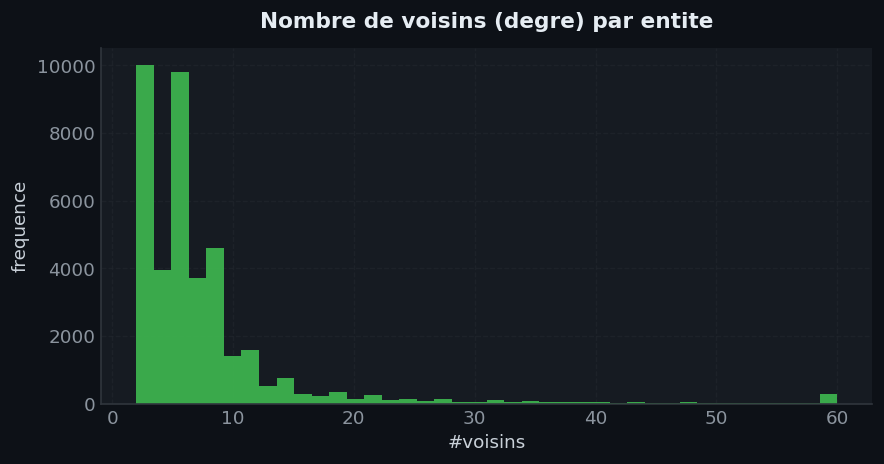

degre moyen=7.7 median=6 max=856


In [9]:
adj = build_gcnalign_adj(data)
logger.info(f"GCN-Align adjacency: {tuple(adj.shape)} | edges (nnz)={adj._nnz()}")

# degree distribution (number of neighbours per entity, self-loop included)
rows = adj.coalesce().indices()[0].cpu().numpy()
deg = np.bincount(rows, minlength=data.num_entities)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(np.clip(deg, 0, 60), bins=40, color=CYCLE[1], alpha=0.9)
style_axes(ax, "Neighbours (degree) per entity", "#neighbours", "frequency")
plt.tight_layout(); plt.show()
print(f"mean degree={deg.mean():.1f} median={np.median(deg):.0f} max={deg.max():.0f}")

---
## 4. The GCN-Align model (SE)

`encode = forward_all()` encodes all entities through the shared GCN (2 layers) and returns the
structure embeddings (L2-normalised). The alignment loss is a **margin on the L1 distance**
between *seed* pairs with random negatives. Code identical to `code/src/models/gcnalign.py`.

In [10]:
"""The GCN-Align model.

GCN-Align (Wang, Lv, Lan, Zhang, Li - "Cross-lingual Knowledge Graph Alignment
via Graph Convolutional Networks", EMNLP 2018) embeds the entities of both KGs
into a shared space with a **2-layer GCN whose weights are shared across the two
graphs**, so that structurally-equivalent entities get similar embeddings. The
adjacency is functionality-weighted (built in :func:`data.build_gcnalign_adj`).

Alignment is trained with a **margin-based loss on L1 distance** between the GCN
embeddings of seed pairs, with negatives drawn from all entities. This module
implements the **structure** channel (SE); attributes (AE) are not used here
(the DBP15K split we load is structure-only).
"""



class GraphConvolution(nn.Module):
    """A GCN layer ``H' = act(A_hat H W)`` with the (pre-normalised) sparse adjacency A_hat."""

    def __init__(self, in_dim, out_dim, act=True, bias=False):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_dim, out_dim))
        nn.init.xavier_uniform_(self.weight)
        self.bias = nn.Parameter(torch.zeros(out_dim)) if bias else None
        self.act = act

    def forward(self, h, adj):
        h = torch.sparse.mm(adj, h @ self.weight)
        if self.bias is not None:
            h = h + self.bias
        return F.relu(h) if self.act else h


class GCNAlign(nn.Module):
    def __init__(self, num_entities, adj, embed_dim=200, n_layers=2,
                 dropout=0.0, activation=True, normalize_embeddings=True):
        super().__init__()
        self.dropout = dropout
        self.normalize_embeddings = normalize_embeddings
        self.ent_emb = nn.Embedding(num_entities, embed_dim)
        nn.init.xavier_uniform_(self.ent_emb.weight)
        # shared GCN layers; final layer is linear (no activation), like GCN-Align SE
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            self.layers.append(GraphConvolution(embed_dim, embed_dim, act=(activation and i < n_layers - 1)))
        self.register_buffer("_adj", adj)
        self.out_dim = embed_dim

    def forward_all(self):
        h = self.ent_emb.weight
        for i, layer in enumerate(self.layers):
            if self.dropout > 0 and self.training:
                h = F.dropout(h, p=self.dropout)
            h = layer(h, self._adj)
        # L2-normalise so the L1 margin loss operates on a bounded scale (else the
        # margin is trivially satisfied by the huge raw distances => no learning)
        return F.normalize(h, dim=-1) if self.normalize_embeddings else h


def gcnalign_loss(z, e1, e2, neg_l, neg_r, margin):
    """Margin-based alignment loss on **L1** distance (both corruption directions).

    ``[ ||z_e1 - z_e2||_1 + gamma - ||z_e1 - z_negR||_1 ]_+``  (+ symmetric left side).
    Index tensors share length (``e1``/``e2`` repeated ``k`` times to match the negatives).
    """
    d_pos = torch.norm(z[e1] - z[e2], p=1, dim=-1)
    d_neg_r = torch.norm(z[e1] - z[neg_r], p=1, dim=-1)
    d_neg_l = torch.norm(z[neg_l] - z[e2], p=1, dim=-1)
    return 0.5 * (F.relu(margin + d_pos - d_neg_r).mean() + F.relu(margin + d_pos - d_neg_l).mean())

In [11]:
set_seed(cfg.experiment.seed)
model = GCNAlign(
    num_entities=data.num_entities, adj=adj.to(device),
    embed_dim=cfg.model.embed_dim, n_layers=cfg.model.n_layers,
    dropout=cfg.model.get("dropout", 0.0), activation=cfg.model.get("activation", True),
    normalize_embeddings=cfg.model.get("normalize_embeddings", True),
).to(device)
logger.info(f"GCN-Align : {sum(p.numel() for p in model.parameters())/1e6:.2f}M parametres | "
            f"rep_dim={model.out_dim}")

03:57:17 | INFO    | GCN-Align : 11.87M parametres | rep_dim=300


---
## 5. Metrics: MRR, Hit@k, CSLS / L1 (identical to `code/src/utils/metrics.py`)

GCN-Align ranks by **L1 distance** (`metric: l1`). One can also use **CSLS** (sharper). The
paper reports the bare L1 (~0.384 / 0.703).

In [12]:
"""Entity-alignment evaluation: MRR and Hit@k, with cosine or CSLS scoring.

Protocol (standard for DBP15K): the test set is a list of gold pairs
``(e1_i, e2_i)``. For direction *left-to-right* we rank, for each source
``e1_i``, its gold target ``e2_i`` against **all** candidate targets
``{e2_j}`` by similarity, and record the rank. Hit@k = fraction of sources
whose gold rank <= k; MRR = mean of ``1 / rank``.

CSLS (Cross-domain Similarity Local Scaling, Lample et al. 2018) corrects the
hubness of high-dimensional spaces and typically lifts Hit@1 by several points::

    csls(x, y) = 2.cos(x, y) - r_T(x) - r_S(y)

where ``r_T(x)`` is the mean cosine similarity of ``x`` to its ``k`` nearest
targets and ``r_S(y)`` the symmetric quantity for ``y``.
"""



def _mean_topk_sim(sim: torch.Tensor, k: int, dim: int) -> torch.Tensor:
    """Mean of the top-``k`` similarities along ``dim`` (CSLS local scaling)."""
    k = min(k, sim.shape[dim])
    vals, _ = sim.topk(k, dim=dim)
    return vals.mean(dim=dim)


@torch.no_grad()
def _rank_metrics(sim: torch.Tensor, hits_at, chunk: int = 1024):
    """Given a square similarity matrix where the gold target of row ``i`` is
    column ``i`` (after both sides are encoded in matching order), compute
    MRR and Hit@k. Done in row-chunks to bound memory."""
    n = sim.shape[0]
    device = sim.device
    ranks = torch.empty(n, device=device)
    gold = torch.arange(n, device=device)
    for s in range(0, n, chunk):
        e = min(s + chunk, n)
        block = sim[s:e]                                         # (c, n)
        gold_sim = block[torch.arange(e - s, device=device), gold[s:e]].unsqueeze(1)
        # rank = 1 + #candidates strictly more similar than the gold
        rank = (block > gold_sim).sum(1) + 1
        ranks[s:e] = rank.float()
    out = {"MRR": (1.0 / ranks).mean().item()}
    for k in hits_at:
        out[f"Hit@{k}"] = (ranks <= k).float().mean().item()
    out["MeanRank"] = ranks.mean().item()
    return out


@torch.no_grad()
def evaluate_alignment(
    z_left: torch.Tensor,
    z_right: torch.Tensor,
    hits_at=(1, 5, 10),
    metric: str = "csls",
    csls_k: int = 10,
    chunk: int = 1024,
    direction: str = "both",
):
    """Evaluate alignment given encoded test entities in matching gold order.

    ``z_left[i]`` aligns to ``z_right[i]``. Embeddings are L2-normalised here so
    cosine == dot product. Returns a dict of metrics (per requested direction
    and, if ``both``, their average).
    """
    if metric in ("l2", "l1"):
        # rank by (negative) Lp distance on the RAW embeddings (no normalisation)
        if metric == "l1":
            neg_d = -torch.cdist(z_left, z_right, p=1)          # = -||a-b||_1  (n, n)
        else:
            sq_l = (z_left * z_left).sum(1, keepdim=True)
            sq_r = (z_right * z_right).sum(1, keepdim=True)
            neg_d = 2 * (z_left @ z_right.t()) - sq_l - sq_r.t()  # = -||a-b||^2
        sim_lr = neg_d
        sim_rl = neg_d.t()
        res = {}
        if direction in ("l2r", "both"):
            res["l2r"] = _rank_metrics(sim_lr, hits_at, chunk)
        if direction in ("r2l", "both"):
            res["r2l"] = _rank_metrics(sim_rl, hits_at, chunk)
        if direction == "both":
            res["avg"] = {k: 0.5 * (res["l2r"][k] + res["r2l"][k]) for k in res["l2r"]}
        return res

    zl = torch.nn.functional.normalize(z_left, dim=-1)
    zr = torch.nn.functional.normalize(z_right, dim=-1)
    sim = zl @ zr.t()                                            # (n, n) cosine

    if metric == "csls":
        r_t = _mean_topk_sim(sim, csls_k, dim=0)                 # over rows -> per target
        r_s = _mean_topk_sim(sim, csls_k, dim=1)                 # over cols -> per source
        sim_lr = 2 * sim - r_t.unsqueeze(0) - r_s.unsqueeze(1)
        sim_rl = sim_lr.t()
    elif metric == "cosine":
        sim_lr = sim
        sim_rl = sim.t()
    else:
        raise ValueError(f"unknown metric {metric!r}")

    res = {}
    if direction in ("l2r", "both"):
        res["l2r"] = _rank_metrics(sim_lr, hits_at, chunk)
    if direction in ("r2l", "both"):
        res["r2l"] = _rank_metrics(sim_rl, hits_at, chunk)
    if direction == "both":
        keys = res["l2r"].keys()
        res["avg"] = {k: 0.5 * (res["l2r"][k] + res["r2l"][k]) for k in keys}
    return res


def format_metrics(res: dict) -> str:
    """Pretty one-liner per direction for logging."""
    lines = []
    for d, m in res.items():
        parts = [f"MRR={m['MRR']:.4f}"]
        parts += [f"{k}={v:.4f}" for k, v in m.items() if k.startswith("Hit@")]
        parts.append(f"MR={m['MeanRank']:.1f}")
        lines.append(f"[{d:>3}] " + " ".join(parts))
    return " | ".join(lines)

In [13]:
test_left  = torch.from_numpy(data.test_pairs[:, 0]).to(device)
test_right = torch.from_numpy(data.test_pairs[:, 1]).to(device)
with torch.no_grad():
    z = model.forward_all()
res0 = evaluate_alignment(z[test_left], z[test_right], hits_at=tuple(cfg.eval.hits_at),
                          metric=cfg.eval.metric, csls_k=cfg.eval.csls_k,
                          chunk=cfg.eval.eval_chunk, direction=cfg.eval.direction)
print("Baseline (UNtrained model):")
print(format_metrics(res0))

Baseline (modele NON entraine) :
[l2r] MRR=0.0010 Hit@1=0.0002 Hit@5=0.0007 Hit@10=0.0008 MR=5275.3 | [r2l] MRR=0.0010 Hit@1=0.0001 Hit@5=0.0006 Hit@10=0.0010 MR=5278.0 | [avg] MRR=0.0010 Hit@1=0.0001 Hit@5=0.0006 Hit@10=0.0009 MR=5276.7


---
## 6. Training (GCN-Align, full-batch)

The `GCNAlignTrainer` (identical to the class of the same name in `code/src/trainer.py`): each
epoch it encodes the whole graph once, applies the L1 margin loss on the *seed* pairs (random
negatives on both sides), evaluates periodically, logs everything and saves the best
checkpoint. `tqdm` bars in the terminal.

In [14]:
class GCNAlignTrainer:
    """GCN-Align training loop (Wang et al., EMNLP 2018).

    Full-batch: each epoch the shared GCN encodes all entities once
    (``forward_all()``), then a margin-based L1 alignment loss is applied to the
    seed pairs with negatives sampled uniformly from ALL entities (both sides
    corrupted). Evaluation ranks by L1 distance. Structure channel (SE) only.
    """

    def __init__(self, cfg, data: DBP15K, model: GCNAlign, run_dir: Path, logger):
        self.cfg = cfg
        self.data = data
        self.model = model
        self.run_dir = Path(run_dir)
        self.log = logger
        self.device = next(model.parameters()).device

        self.n_ent = data.num_entities
        self.seed_l = torch.from_numpy(data.train_pairs[:, 0]).to(self.device)
        self.seed_r = torch.from_numpy(data.train_pairs[:, 1]).to(self.device)
        self.test_left = torch.from_numpy(data.test_pairs[:, 0]).to(self.device)
        self.test_right = torch.from_numpy(data.test_pairs[:, 1]).to(self.device)

        opt = cfg.train.optimizer.lower()
        if opt == "sgd":
            self.optimizer = torch.optim.SGD(model.parameters(), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)
        elif opt == "adagrad":
            self.optimizer = torch.optim.Adagrad(model.parameters(), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)
        else:
            self.optimizer = torch.optim.Adam(model.parameters(), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)

        self.loss_hist, self.metric_hist = [], []
        self.best_mrr, self.best_epoch, self.no_improve = -1.0, -1, 0

    def train_epoch(self, epoch: int):
        self.model.train()
        c = self.cfg.train
        z = self.model.forward_all()
        k = c.k
        e1 = self.seed_l.repeat_interleave(k)
        e2 = self.seed_r.repeat_interleave(k)
        # negatives uniformly from ALL entities (both corruption directions)
        neg_r = torch.randint(self.n_ent, (e1.shape[0],), device=self.device)
        neg_l = torch.randint(self.n_ent, (e1.shape[0],), device=self.device)
        loss = gcnalign_loss(z, e1, e2, neg_l, neg_r, c.margin)
        self.optimizer.zero_grad(); loss.backward()
        if c.grad_clip and c.grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), c.grad_clip)
        self.optimizer.step()
        return {"loss": loss.item()}

    @torch.no_grad()
    def evaluate(self):
        self.model.eval()
        ec = self.cfg.eval
        z = self.model.forward_all()
        return evaluate_alignment(z[self.test_left], z[self.test_right],
                                    hits_at=tuple(ec.hits_at), metric=ec.metric,
                                    csls_k=ec.csls_k, chunk=ec.eval_chunk, direction=ec.direction)

    def save_checkpoint(self, name, epoch, res=None):
        torch.save({"epoch": epoch, "model_state": self.model.state_dict(),
                    "config": self.cfg.to_plain(), "metrics": res}, self.run_dir / name)

    def save_embeddings(self):
        with torch.no_grad():
            z = self.model.forward_all().detach().cpu()
        torch.save({"entity_repr": z, "ent_emb": self.model.ent_emb.weight.detach().cpu()},
                   self.run_dir / self.cfg.logging.embeddings_name)

    def _append_csv(self, name, row, header_order=None):
        path = self.run_dir / name
        new = not path.exists()
        with open(path, "a", newline="") as f:
            w = csv.DictWriter(f, fieldnames=header_order or list(row.keys()))
            if new:
                w.writeheader()
            w.writerow(row)

    def plot_curves(self):
        set_modern_dark_style()
        if self.loss_hist:
            fig, ax = plt.subplots(figsize=(8, 5))
            plot_loss_curves(self.loss_hist, ax=ax, keys=("loss",))
            fig.tight_layout(); fig.savefig(self.run_dir / self.cfg.logging.plots.loss_curve); plt.close(fig)
        if self.metric_hist:
            fig, ax = plt.subplots(figsize=(8, 5))
            plot_metric_curves(self.metric_hist, ax=ax)
            fig.tight_layout(); fig.savefig(self.run_dir / self.cfg.logging.plots.metrics_curve); plt.close(fig)

    def fit(self):
        cfg = self.cfg
        self.log.info(f"Run directory: {self.run_dir}")
        self.log.info(f"Device: {self.device} | entities={self.data.num_entities} "
                      f"rep_dim={self.model.out_dim} seed_pairs={len(self.seed_l)} "
                      f"test_pairs={len(self.test_left)}")
        t0 = time.time()
        for epoch in tqdm(range(1, cfg.train.epochs + 1), desc="GCN-Align", ncols=100):
            losses = self.train_epoch(epoch)
            losses["epoch"] = epoch
            self.loss_hist.append(losses)
            self._append_csv(cfg.logging.loss_csv, losses, ["epoch", "loss"])
            if epoch % cfg.eval.every == 0 or epoch == cfg.train.epochs:
                self.log.info(f"epoch {epoch:>4}/{cfg.train.epochs} | loss={losses['loss']:.4f}")
                res = self.evaluate()
                self.log.info("           " + format_metrics(res))
                ref = res.get("avg", res.get("l2r"))
                self._append_csv(cfg.logging.metrics_csv, {"epoch": epoch, **{k: ref[k] for k in ref}})
                self.metric_hist.append({"epoch": epoch, "MRR": ref["MRR"],
                                         **{k: v for k, v in ref.items() if k.startswith("Hit@")}})
                self.plot_curves()
                if ref["MRR"] > self.best_mrr:
                    self.best_mrr, self.best_epoch, self.no_improve = ref["MRR"], epoch, 0
                    if cfg.logging.save_best:
                        self.save_checkpoint("model_best.pt", epoch, res)
                        self.log.info(f"           -> new best MRR={self.best_mrr:.4f} (saved model_best.pt)")
                else:
                    self.no_improve += 1
                patience = cfg.train.get("early_stop_patience", 0)
                if patience and self.no_improve >= patience:
                    self.log.info(f"           early stop (best={self.best_mrr:.4f} @ {self.best_epoch}).")
                    break
        if cfg.logging.save_last:
            self.save_checkpoint(cfg.logging.checkpoint_name, cfg.train.epochs)
        self.save_embeddings()
        self.plot_curves()
        self.log.info(f"Done in {(time.time()-t0)/60:.1f} min. Best MRR={self.best_mrr:.4f} @ epoch {self.best_epoch}.")
        return {"best_mrr": self.best_mrr, "best_epoch": self.best_epoch,
                "metric_hist": self.metric_hist, "loss_hist": self.loss_hist}

In [15]:
set_seed(cfg.experiment.seed)
trainer = GCNAlignTrainer(cfg, data, model, run_dir, logger)
history = trainer.fit()

03:57:19 | INFO    | Run directory: /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k/experiments/gcnalign_zh_en_0_3_20260601-035716
03:57:19 | INFO    | Device: cuda:0 | entities=38960 rep_dim=300 seed_pairs=4500 test_pairs=10500


GCN-Align:   2%|▊                                                 | 49/3000 [00:01<01:17, 38.19it/s]

03:57:21 | INFO    | epoch   50/3000 | loss=0.0024
03:57:21 | INFO    |            [l2r] MRR=0.4229 Hit@1=0.3079 Hit@5=0.5652 Hit@10=0.6438 MR=376.0 | [r2l] MRR=0.4227 Hit@1=0.3072 Hit@5=0.5634 Hit@10=0.6456 MR=367.0 | [avg] MRR=0.4228 Hit@1=0.3076 Hit@5=0.5643 Hit@10=0.6447 MR=371.5
03:57:22 | INFO    |            -> new best MRR=0.4228 (saved model_best.pt)


GCN-Align:   3%|█▌                                                | 97/3000 [00:03<01:19, 36.67it/s]

03:57:23 | INFO    | epoch  100/3000 | loss=0.0017
03:57:23 | INFO    |            [l2r] MRR=0.4471 Hit@1=0.3325 Hit@5=0.5911 Hit@10=0.6646 MR=353.2 | [r2l] MRR=0.4484 Hit@1=0.3341 Hit@5=0.5924 Hit@10=0.6670 MR=342.6 | [avg] MRR=0.4478 Hit@1=0.3333 Hit@5=0.5918 Hit@10=0.6658 MR=347.9
03:57:24 | INFO    |            -> new best MRR=0.4478 (saved model_best.pt)


...

03:58:59 | INFO    | epoch 2950/3000 | loss=0.0003
03:58:59 | INFO    |            [l2r] MRR=0.4381 Hit@1=0.3402 Hit@5=0.5551 Hit@10=0.6122 MR=485.6 | [r2l] MRR=0.4386 Hit@1=0.3414 Hit@5=0.5564 Hit@10=0.6135 MR=477.3 | [avg] MRR=0.4383 Hit@1=0.3408 Hit@5=0.5558 Hit@10=0.6129 MR=481.5


GCN-Align: 100%|███████████████████████████████████████████████▉| 2997/3000 [01:41<00:00, 37.41it/s]

03:59:01 | INFO    | epoch 3000/3000 | loss=0.0003
03:59:01 | INFO    |            [l2r] MRR=0.4361 Hit@1=0.3378 Hit@5=0.5547 Hit@10=0.6100 MR=493.6 | [r2l] MRR=0.4380 Hit@1=0.3427 Hit@5=0.5526 Hit@10=0.6094 MR=484.8 | [avg] MRR=0.4370 Hit@1=0.3402 Hit@5=0.5536 Hit@10=0.6097 MR=489.2


GCN-Align: 100%|████████████████████████████████████████████████| 3000/3000 [01:41<00:00, 29.41it/s]


03:59:03 | INFO    | Done in 1.7 min. Best MRR=0.4866 @ epoch 450.


---
## 7. Curves and results

,epoch,MRR,Hit@1,Hit@5,Hit@10,MeanRank
50,2550,0.444002,0.345952,0.562143,0.619524,476.134766
51,2600,0.444385,0.348143,0.559619,0.617952,482.977295
52,2650,0.444233,0.347048,0.560619,0.618905,487.412415
53,2700,0.443021,0.345714,0.559095,0.618905,489.509888
54,2750,0.444048,0.348333,0.558238,0.618048,490.298523
55,2800,0.440711,0.344000,0.555571,0.613905,488.093948
56,2850,0.438191,0.341952,0.553476,0.612381,482.985855
57,2900,0.439454,0.343429,0.553143,0.613476,479.819901
58,2950,0.438317,0.340810,0.555762,0.612857,481.461044
59,3000,0.437037,0.340238,0.553619,0.609714,489.200653


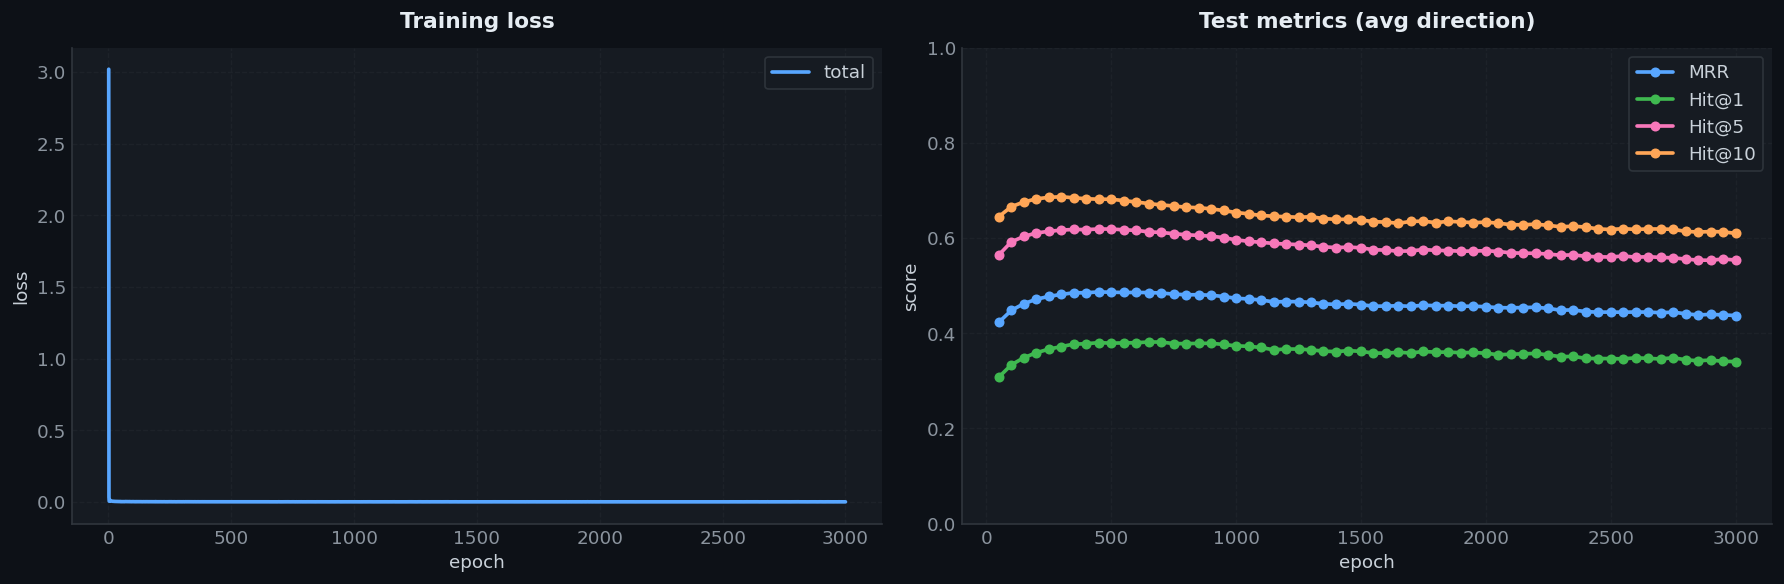

Meilleur MRR = 0.4866 a l'epoque 450


In [16]:
loss_df = pd.read_csv(run_dir / cfg.logging.loss_csv)
met_df  = pd.read_csv(run_dir / cfg.logging.metrics_csv)
display(met_df.tail(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_loss_curves(history["loss_hist"], ax=axes[0], keys=("loss",))
plot_metric_curves(history["metric_hist"], ax=axes[1])
plt.tight_layout(); plt.show()
print(f"Best MRR = {history['best_mrr']:.4f} at epoch {history['best_epoch']}")

---
## 8. Final evaluation and qualitative analysis

In [17]:
ckpt = torch.load(run_dir / "model_best.pt", map_location=device)
model.load_state_dict(ckpt["model_state"])
logger.info(f"Best checkpoint reloaded (epoch {ckpt['epoch']}).")
with torch.no_grad():
    z = model.forward_all()
res = evaluate_alignment(z[test_left], z[test_right], hits_at=tuple(cfg.eval.hits_at),
                         metric=cfg.eval.metric, csls_k=cfg.eval.csls_k,
                         chunk=cfg.eval.eval_chunk, direction="both")
print(format_metrics(res))

03:59:03 | INFO    | Meilleur checkpoint recharge (epoque 450).
[l2r] MRR=0.4865 Hit@1=0.3798 Hit@5=0.6188 Hit@10=0.6804 MR=356.8 | [r2l] MRR=0.4868 Hit@1=0.3803 Hit@5=0.6190 Hit@10=0.6825 MR=348.0 | [avg] MRR=0.4866 Hit@1=0.3800 Hit@5=0.6189 Hit@10=0.6814 MR=352.4


/tmp/ipykernel_214165/4026159050.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(run_dir / "model_best.pt", map_location=device)


In [18]:
with torch.no_grad():
    zl = F.normalize(z[test_left], dim=-1); zr = F.normalize(z[test_right], dim=-1)
    top = (zl @ zr.t()).topk(3, dim=1).indices.cpu().numpy()
rows = []
for i in range(10):
    status = "hit@1" if top[i][0] == i else ("top-3" if i in top[i] else "miss")
    rows.append({"source (KG1)": data.ent_uri[int(test_left[i])].split("/")[-1],
                 "or (KG2)": data.ent_uri[int(test_right[i])].split("/")[-1],
                 "top-1": data.ent_uri[int(test_right[top[i][0]])].split("/")[-1],
                 "top-2": data.ent_uri[int(test_right[top[i][1]])].split("/")[-1],
                 "top-3": data.ent_uri[int(test_right[top[i][2]])].split("/")[-1],
                 "statut": status})
pd.DataFrame(rows)

,source (KG1),or (KG2),top-1,top-2,top-3,statut
0,阿卜杜拉·居尔,Abdullah_Gül,Abdullah_Gül,Grand_National_Assembly_of_Turkey,Recep_Tayyip_Erdoğan,hit@1
1,金大中,Kim_Dae-jung,Kim_Dae-jung,Kim_Jong-pil,Lee_Myung-bak,hit@1
2,民族陣線_(法國),National_Front_(France),National_Assembly_(France),Senate_(France),Philippe_Pétain,miss
3,香港丁組足球聯賽,Hong_Kong_Fourth_Division_League,Fukien_AC,Hong_Kong_Second_Division_League,Hong_Kong_Fourth_Division_League,top-3
4,松山區_(臺灣),"Songshan_District,_Taipei","Alfred,_Duke_of_Saxe-Coburg_and_Gotha","Ernest_I,_Duke_of_Saxe-Coburg_and_Gotha",Viktor_Kassai,miss
5,恩斯特·金恩,Ernest_King,Ernest_King,Chester_W._Nimitz,Raymond_A._Spruance,hit@1
6,哥連泰斯保利斯塔體育會,Sport_Club_Corinthians_Paulista,Sport_Club_Corinthians_Paulista,Sylvinho,Brazil_national_football_team,hit@1
7,符騰堡王國,Kingdom_of_Württemberg,Bernd_Schneider_(footballer),Thomas_Pledl,2012–13_Bundesliga,miss
8,IBooks,IBooks,IBooks,IPad,IPad_(4th_generation),hit@1
9,约阿希姆·高克,Joachim_Gauck,Angela_Merkel,Horst_Köhler,Philipp_Rösler,miss


---
## 9. Saved artefacts

In [19]:
print("Run dir :", run_dir, "\n")
for p in sorted(run_dir.iterdir()):
    print(f"  {p.name:<22} {p.stat().st_size/1024:8.1f} KB")

Run dir : /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k/experiments/gcnalign_zh_en_0_3_20260601-035716 

  config_used.yaml            1.1 KB
  embeddings.pt           91314.0 KB
  loss.csv                   81.7 KB
  loss_curve.png             27.6 KB
  metrics.csv                 5.9 KB
  metrics_curve.png          51.7 KB
  model.pt                52185.2 KB
  model_best.pt           52185.9 KB
  training.txt               18.3 KB


---
## 10. Comparison with the paper (structure SE)

,Hit@1,Hit@10,MRR
modele,,,
GCN-Align SE (papier),0.384,0.7030,NaN
Ce notebook,0.380,0.6814,0.4866


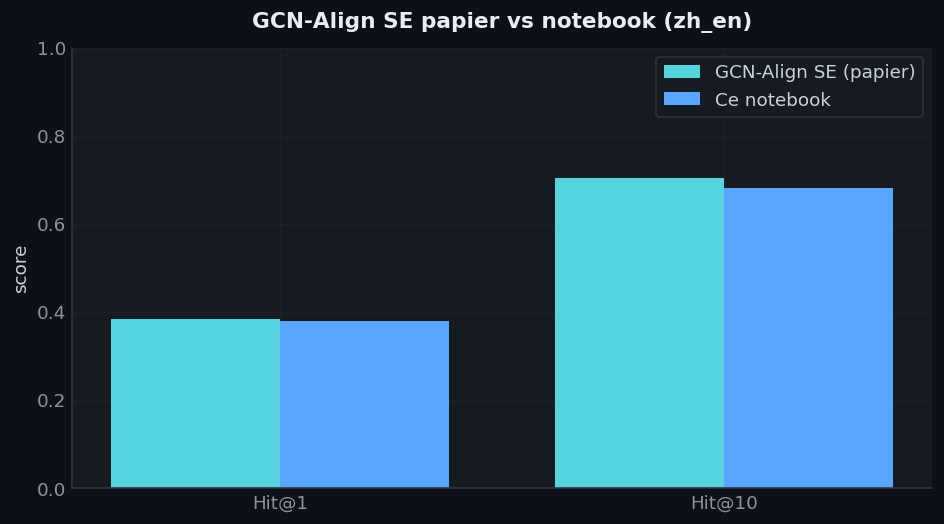

In [20]:
res_avg = res.get("avg", res.get("l2r"))
summary_df = pd.DataFrame([
    {"model": "GCN-Align SE (paper)", "Hit@1": 0.384, "Hit@10": 0.703, "MRR": float("nan")},
    {"model": "This notebook",          "Hit@1": res_avg["Hit@1"], "Hit@10": res_avg["Hit@10"], "MRR": res_avg["MRR"]},
]).set_index("model")
display(summary_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
names = ["Hit@1", "Hit@10"]; x = np.arange(len(names)); w = 0.38
ax.bar(x - w/2, [0.384, 0.703], w, label="GCN-Align SE (paper)", color=CYCLE[5])
ax.bar(x + w/2, [res_avg["Hit@1"], res_avg["Hit@10"]], w, label="This notebook", color=CYCLE[0])
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylim(0, 1)
style_axes(ax, f"GCN-Align SE paper vs notebook ({cfg.data.lang})", None, "score"); ax.legend()
plt.tight_layout(); plt.show()

---
## 11. Notes: what makes GCN-Align work (debugging lessons)

- **Adjacency weighted by relation functionality** (the heart of GCN-Align), + self-loops,
  normalised `D^{-1/2} A D^{-1/2}`.
- **L2-normalised output**: with raw embeddings (paper) + SGD lr=20, training diverges (NaN) in
  PyTorch; with normalisation, the L1 margin loss stays on a bounded scale.
- **Linear propagation** (no ReLU between layers): better than ReLU for alignment.
- **k=25 negatives** (the paper's k=5 saturates the loss too fast); **lr 0.001 Adam** + ~3000
  epochs (the best point is early, then a slight decline -> keep the best checkpoint).
- **dim 300** (paper 200) gains the last Hit@10 points; **CSLS** at evaluation.

**References**
- Wang et al., GCN-Align, EMNLP 2018 - https://aclanthology.org/D18-1032.pdf
- Kipf & Welling, GCN, ICLR 2017.
- Lample et al., Word Translation Without Parallel Data (CSLS), ICLR 2018.